In [1]:
#Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import database as DF

df = pd.read_csv('MiningProcess_Flotation_Plant_Database.csv')

In [3]:
#Missing values and basic descriptive stats

print("=== SHAPE ===")
print(df.shape)
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values")
print("\n=== BASIC STATS ===")
print(df.describe().round(2))

=== SHAPE ===
(737453, 24)

=== MISSING VALUES ===
No missing values

=== BASIC STATS ===
                       date % Iron Feed % Silica Feed Starch Flow Amina Flow  \
count                737453      737453        737453      737453     737453   
unique                 4097         278           293      409317     319416   
top     2017-03-10 02:00:00       64,03          6,26      2562,5    534,668   
freq                    180      142560        142560         690        959   

       Ore Pulp Flow Ore Pulp pH Ore Pulp Density  \
count         737453      737453           737453   
unique        180189      131143           105805   
top          402,246     10,0591             1,75   
freq            1735        1509             3214   

       Flotation Column 01 Air Flow Flotation Column 02 Air Flow  ...  \
count                        737453                       737453  ...   
unique                        43675                        80442  ...   
top                     

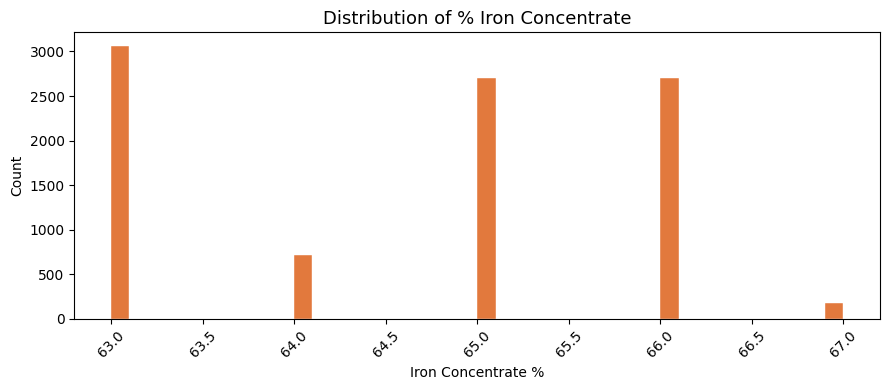

In [11]:
#Histogram to check the distribution of % Iron Concentrate

df['% Iron Concentrate'] = pd.to_numeric(df['% Iron Concentrate'], errors='coerce')
df = df[['date', '% Iron Concentrate']].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['% Iron Concentrate'].dropna(), bins=40, color='#E2793D', edgecolor='white', linewidth=0.3)
ax.set_title('Distribution of % Iron Concentrate', fontsize=13)
ax.set_xlabel('Iron Concentrate %')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

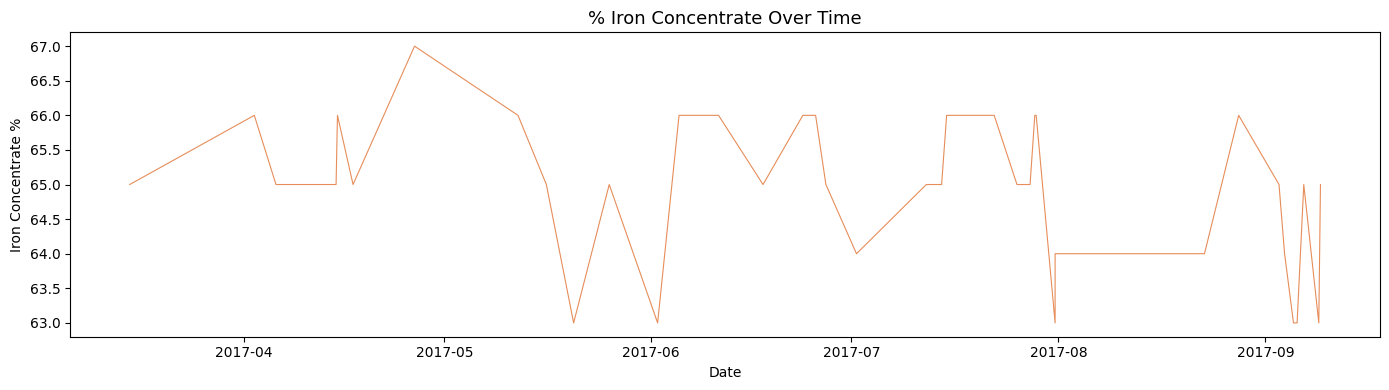

In [12]:
#Over time distribution of % Iron Concentrate

df = df[['date', '% Iron Concentrate']].dropna()
df['% Iron Concentrate'] = df['% Iron Concentrate'].astype(str).str.replace(',', '.').astype(float)
df['date'] = pd.to_datetime(df['date'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['% Iron Concentrate'], color='#E2793D', linewidth=0.8, alpha=0.85)
ax.set_title('% Iron Concentrate Over Time', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Iron Concentrate %')
plt.tight_layout()
plt.show()

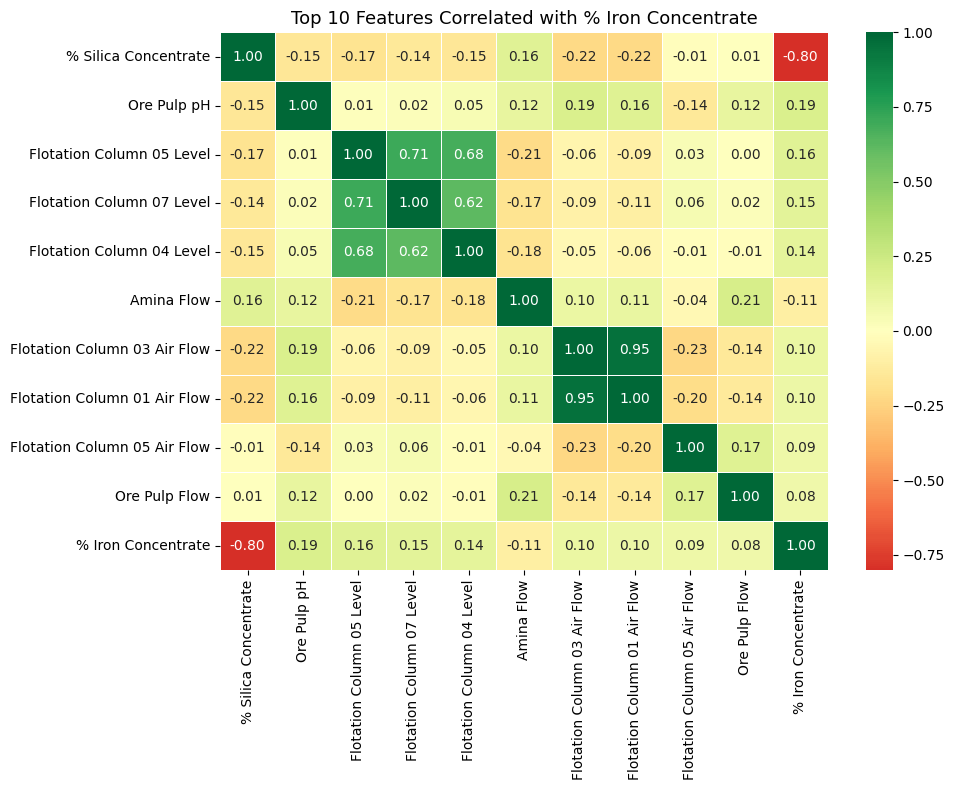

In [17]:
#Correlation heatmap between variables

df = pd.read_csv("MiningProcess_Flotation_Plant_Database.csv", decimal=",")
df['date'] = pd.to_datetime(df['date'])

target_col = "% Iron Concentrate"
top_n = 10
numeric_df = df.select_dtypes(include='number').dropna(subset=[target_col])

corr = numeric_df.corr()[target_col].drop(target_col)
top = corr.abs().nlargest(top_n).index
corr_matrix = numeric_df[list(top) + [target_col]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title(f'Top {top_n} Features Correlated with {target_col}', fontsize=13)
plt.tight_layout()
plt.show()